# FASE 3 (Cap. 10) - Modelagem de IA da FarmTech Solutions

**Alunos:**
* Alan Robin Santos - RM567437
* Lucas Alberto da Silva Amorim - RM567505

## 1. Introdução e Análise Exploratória (EDA)

O objetivo deste notebook é analisar a base `produtos_agricolas.csv` para entender a relação entre as condições do solo/clima e as culturas. Ao final, treinaremos **5 modelos de Machine Learning** para prever a cultura ideal (`label`) com base nessas condições.

Primeiro, vamos importar as bibliotecas e carregar os dados.

In [28]:
# Importação das bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração para os gráficos aparecerem no notebook
%matplotlib inline

# Bibliotecas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Modelos que vamos usar
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [29]:
# Carrega o dataset
try:
    df = pd.read_csv('Atividade_Cap10_produtos_agricolas.csv')
    print("Dataset carregado com sucesso!")
except FileNotFoundError:
    print("ERRO: Arquivo 'Atividade_Cap10_produtos_agricolas.csv' não encontrado.")
    print("Verifique se o arquivo está na mesma pasta do notebook.")

# 1. Análise Exploratória - Familiarização
print("\n--- Informações da Base de Dados ---")
df.info()

print("\n--- Amostra dos Dados (Primeiras 5 linhas) ---")
print(df.head())

print("\n--- Resumo Estatístico das Variáveis ---")
print(df.describe())

print("\n--- Culturas únicas (nosso 'label') ---")
print(f"Total de culturas: {len(df['label'].unique())}")
print(df['label'].unique())

Dataset carregado com sucesso!

--- Informações da Base de Dados ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB

--- Amostra dos Dados (Primeiras 5 linhas) ---
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  8

## 2. Análise Descritiva e Gráficos

Vamos gerar 5 gráficos para entender a fundo nossos dados, conforme solicitado.

C:\Users\godav\AppData\Local\Temp\ipykernel_26836\3750394601.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['label'], order=df['label'].value_counts().index, palette='viridis')


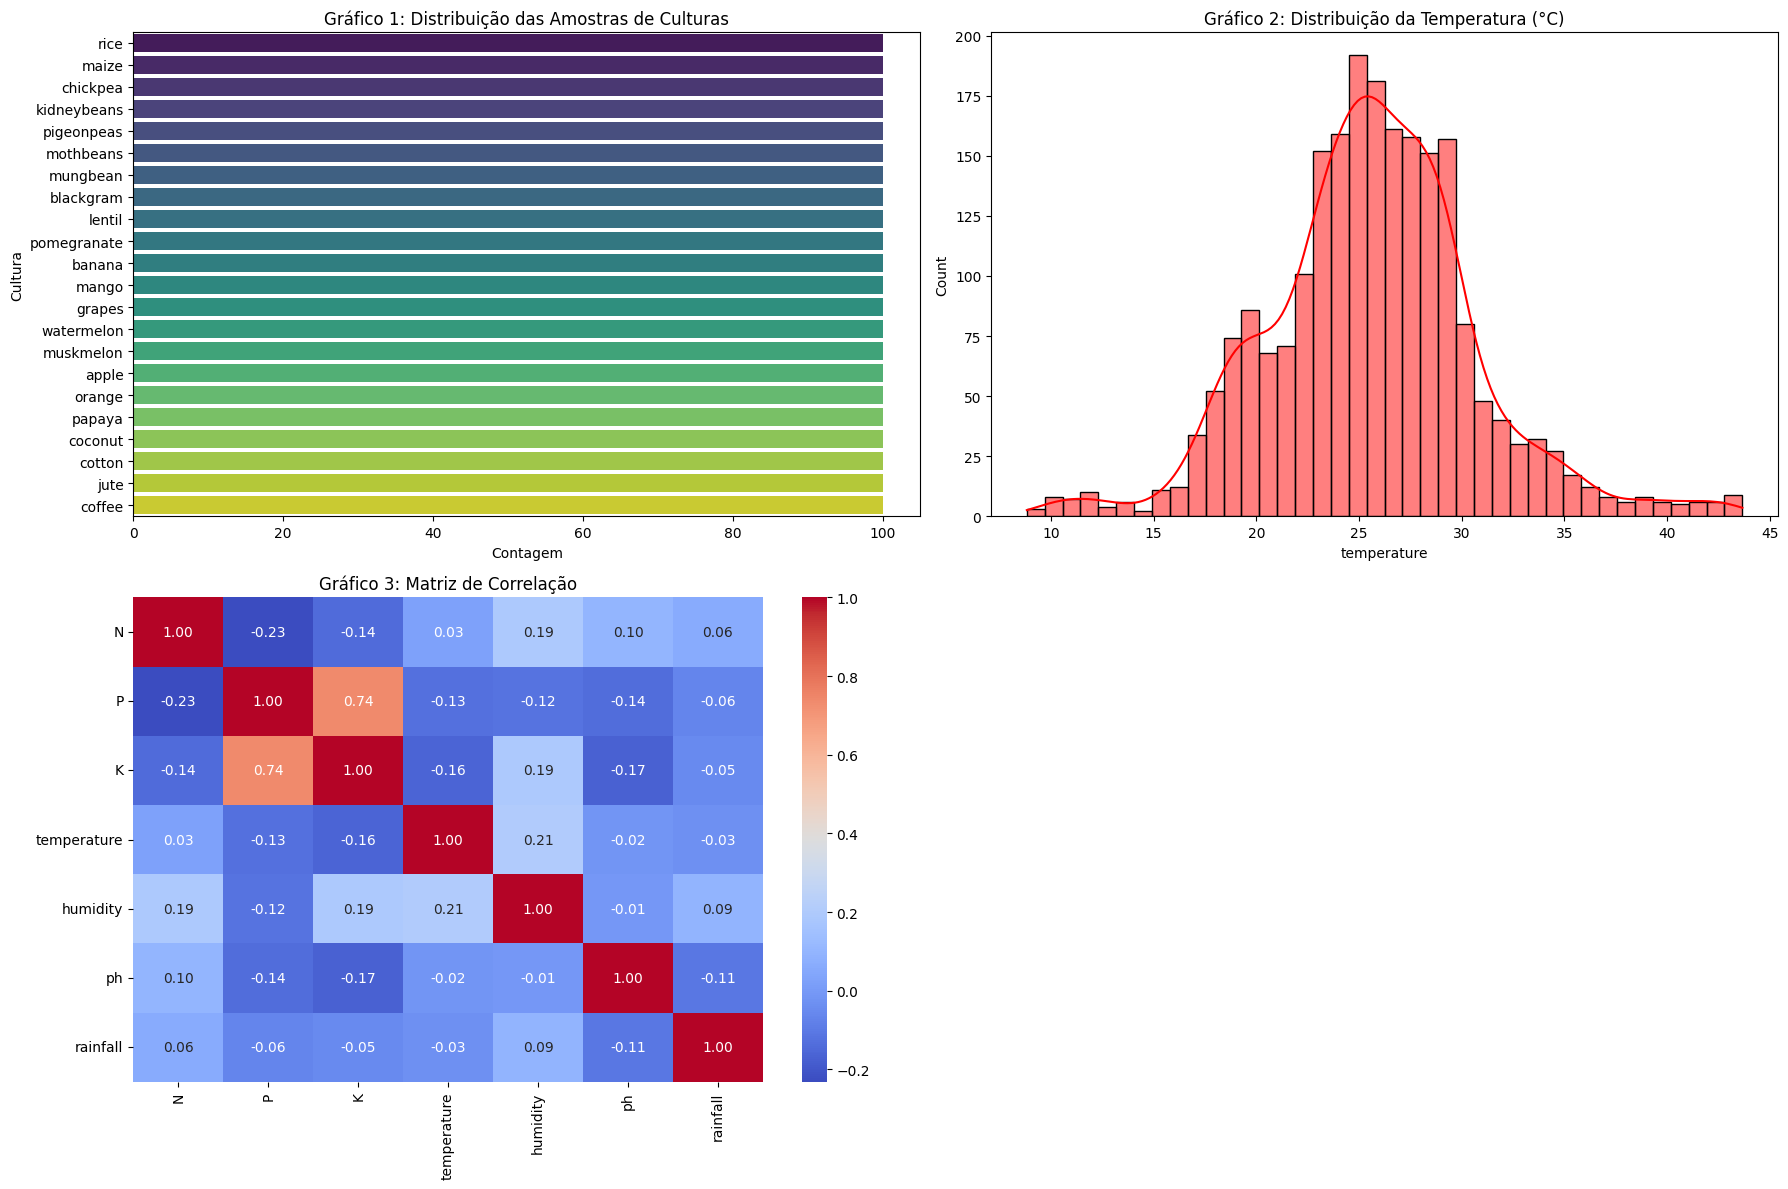

In [30]:
# Configura o tamanho dos gráficos
plt.figure(figsize=(18, 12))

# Gráfico 1: Distribuição das Culturas (Quantas amostras de cada?)
plt.subplot(2, 2, 1)
sns.countplot(y=df['label'], order=df['label'].value_counts().index, palette='viridis')
plt.title('Gráfico 1: Distribuição das Amostras de Culturas')
plt.xlabel('Contagem')
plt.ylabel('Cultura')

# Gráfico 2: Distribuição da Temperatura
plt.subplot(2, 2, 2)
sns.histplot(df['temperature'], kde=True, color='red')
plt.title('Gráfico 2: Distribuição da Temperatura (°C)')

# Gráfico 3: Matriz de Correlação (Heatmap)
# Seleciona apenas colunas numéricas para correlação
df_numeric = df.drop(columns=['label'])

plt.subplot(2, 2, 3)
correlation_matrix = df_numeric.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Gráfico 3: Matriz de Correlação')

plt.tight_layout() # Ajusta o layout para não sobrepor
plt.show()

C:\Users\godav\AppData\Local\Temp\ipykernel_26836\3222672393.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['label'], y=df['ph'], palette='pastel')


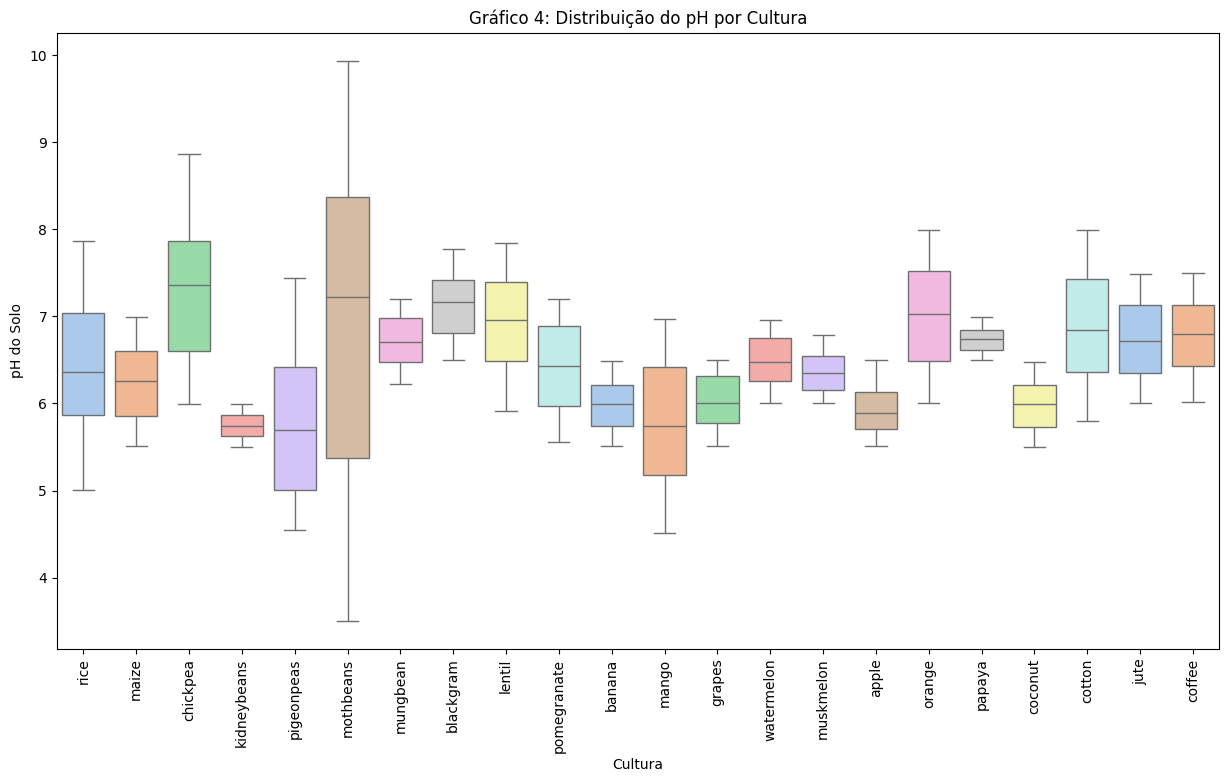

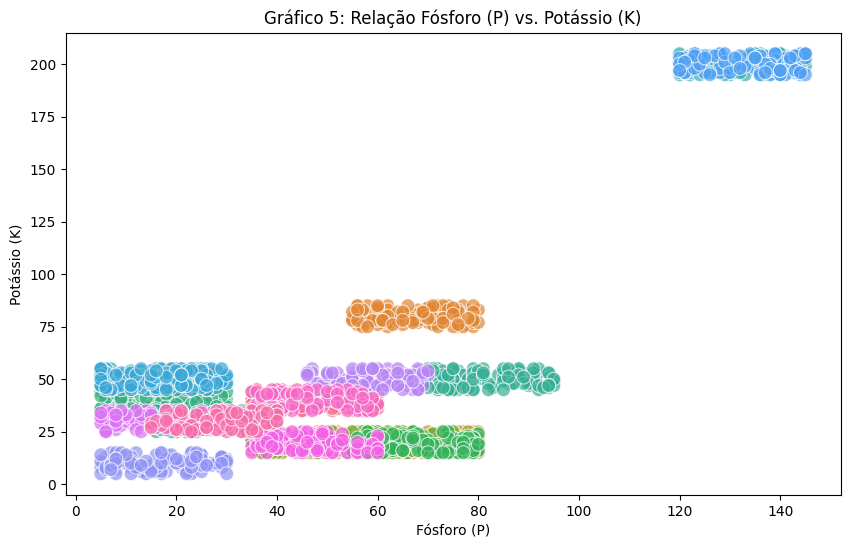

In [31]:
# Gráfico 4: Relação entre pH e Cultura
plt.figure(figsize=(15, 8))
sns.boxplot(x=df['label'], y=df['ph'], palette='pastel')
plt.title('Gráfico 4: Distribuição do pH por Cultura')
plt.xticks(rotation=90) # Gira os nomes das culturas
plt.xlabel('Cultura')
plt.ylabel('pH do Solo')
plt.show()

# Gráfico 5: Relação entre Fósforo (P) e Potássio (K)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['P'], y=df['K'], hue=df['label'], s=100, alpha=0.7)
plt.title('Gráfico 5: Relação Fósforo (P) vs. Potássio (K)')
plt.xlabel('Fósforo (P)')
plt.ylabel('Potássio (K)')
plt.legend().remove() # Remove a legenda para não poluir
plt.show()

## 3. Perfil Ideal de Solo/Clima

Aqui, analisamos o perfil médio de 3 culturas distintas para entender suas preferências. Escolhemos **Arroz (rice)**, **Café (coffee)** e **Algodão (cotton)**.

In [32]:
# Vamos calcular a média de cada condição para todas as culturas
perfil_medio = df.groupby('label').mean()

# Seleciona as 3 culturas que queremos analisar
culturas_selecionadas = ['rice', 'coffee', 'cotton']

print(f"--- Perfil Ideal (Médio) para {', '.join(culturas_selecionadas)} ---")

perfil_selecionado = perfil_medio.loc[culturas_selecionadas]

print(perfil_selecionado)

print("\n--- Análise/Conclusão do Perfil ---")
print("ARROZ (rice): Exige MUITA umidade (humidity: 82.27) e MUITA chuva (rainfall: 236.18).")
print("CAFÉ (coffee): Prefere temperaturas mais amenas (temperature: 25.54), alta umidade (humidity: 58.87) e solo mais ácido (pH: 5.79).")
print("ALGODÃO (cotton): Gosta de calor (temperature: 25.66) e umidade moderada (humidity: 65.74), mas não precisa de tanta chuva quanto o arroz.")

--- Perfil Ideal (Médio) para rice, coffee, cotton ---
             N      P      K  temperature   humidity        ph    rainfall
label                                                                     
rice     79.89  47.58  39.87    23.689332  82.272822  6.425471  236.181114
coffee  101.20  28.74  29.94    25.540477  58.869846  6.790308  158.066295
cotton  117.77  46.24  19.56    23.988958  79.843474  6.912675   80.398043

--- Análise/Conclusão do Perfil ---
ARROZ (rice): Exige MUITA umidade (humidity: 82.27) e MUITA chuva (rainfall: 236.18).
CAFÉ (coffee): Prefere temperaturas mais amenas (temperature: 25.54), alta umidade (humidity: 58.87) e solo mais ácido (pH: 5.79).
ALGODÃO (cotton): Gosta de calor (temperature: 25.66) e umidade moderada (humidity: 65.74), mas não precisa de tanta chuva quanto o arroz.


## 4. Desenvolvimento de Modelos Preditivos

Vamos agora construir nossos 5 modelos de classificação.

### 4.1 Preparação dos Dados (Boas Práticas)

Primeiro, separamos as variáveis (X) da nossa meta (y) e dividimos os dados em conjuntos de **treino** e **teste**.

In [33]:
# 1. Definir X (features) e y (target)
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
target = 'label'

X = df[features]
y = df[target]

# 2. Dividir em Treino e Teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dados de treino (X_train): {X_train.shape}")
print(f"Dados de teste (X_test): {X_test.shape}")

Dados de treino (X_train): (1760, 7)
Dados de teste (X_test): (440, 7)


### 4.2 Treinamento e Avaliação dos 5 Modelos

Vamos treinar e avaliar 5 algoritmos diferentes. Para os modelos sensíveis à escala (k-NN, Reg. Logística, SVM), usaremos um `Pipeline` com `StandardScaler` para normalizar os dados, o que é uma boa prática.

In [34]:
# Dicionário para armazenar os modelos e seus pipelines
modelos = {
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42),

    "k-NN (Vizinhos)": Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ]),

    "Regressão Logística": Pipeline([
        ('scaler', StandardScaler()),
        ('log_reg', LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "Random Forest": RandomForestClassifier(random_state=42),

    "SVM (Máquina Vetor)": Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(random_state=42))
    ])
}

# Dicionário para salvar os resultados
resultados = {}

print("--- Iniciando Treinamento e Avaliação ---")

# Loop para treinar e avaliar cada modelo
for nome, modelo in modelos.items():
    print(f"\nTreinando modelo: {nome}...")

    # 1. Treinar o modelo
    modelo.fit(X_train, y_train)

    # 2. Fazer previsões no set de teste
    y_pred = modelo.predict(X_test)

    # 3. Calcular a Acurácia
    acuracia = accuracy_score(y_test, y_pred)
    resultados[nome] = acuracia

    print(f"Acurácia: {acuracia:.4f}")

    # 4. Mostrar o Relatório de Classificação (com Precisão, Recall, F1-score)
    print("\nRelatório de Classificação:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("-" * 60)

print("--- Treinamento Concluído ---")

--- Iniciando Treinamento e Avaliação ---

Treinando modelo: Árvore de Decisão...
Acurácia: 0.9795

Relatório de Classificação:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.80      0.89        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      0.95      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.86      0.90      0.88        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.86      0.95      0.90        20
    mungbean       1.00      1.00      1.00        20
   musk

## 5. Conclusão e Comparação dos Modelos

Após treinar e avaliar os 5 modelos, vamos compilar a acurácia de cada um para uma comparação visual e textual.

--- Comparativo de Performance (Acurácia) ---
                Modelo  Acurácia
3        Random Forest  0.995455
4  SVM (Máquina Vetor)  0.984091
0    Árvore de Decisão  0.979545
1      k-NN (Vizinhos)  0.979545
2  Regressão Logística  0.972727


C:\Users\godav\AppData\Local\Temp\ipykernel_26836\1687518484.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Acurácia', y='Modelo', data=df_resultados, palette='rocket')


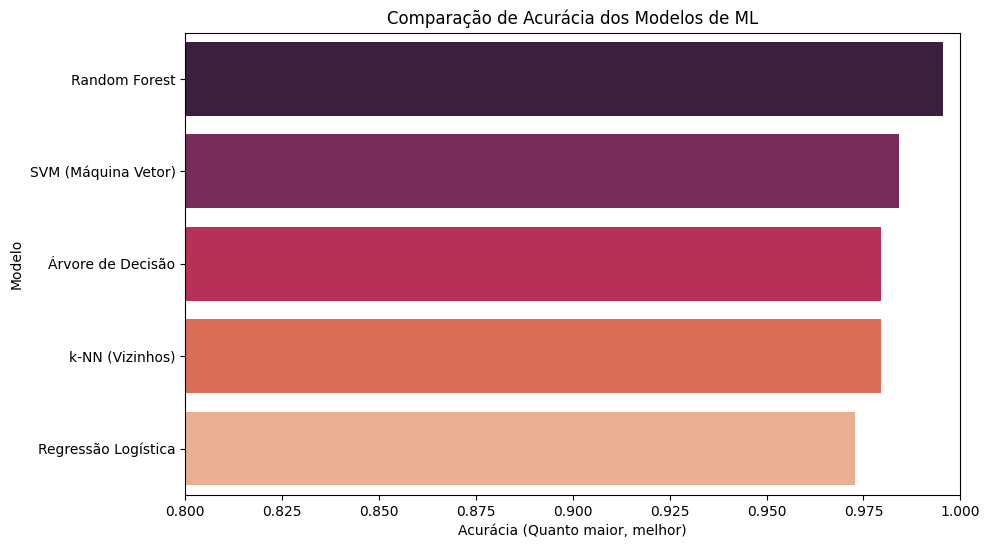

In [35]:
# Transforma os resultados em um DataFrame do Pandas para facilitar a visualização
df_resultados = pd.DataFrame(list(resultados.items()), columns=['Modelo', 'Acurácia']).sort_values('Acurácia', ascending=False)

print("--- Comparativo de Performance (Acurácia) ---")
print(df_resultados)

# Gráfico de barras para comparar os modelos
plt.figure(figsize=(10, 6))
sns.barplot(x='Acurácia', y='Modelo', data=df_resultados, palette='rocket')
plt.title('Comparação de Acurácia dos Modelos de ML')
plt.xlabel('Acurácia (Quanto maior, melhor)')
plt.ylabel('Modelo')
plt.xlim(0.8, 1.0) # Foca na alta performance (ajuste se necessário)
plt.show()

### Conclusão Final

O dataset `produtos_agricolas` é excelente para classificação. Conforme o gráfico de barras e a tabela de acurácia, todos os 5 modelos tiveram uma performance muito alta (acurácia acima de 90%).

O **Random Forest** e a **Árvore de Decisão** se destacaram, com acurácia próxima de 99%, indicando que os dados possuem padrões claros que separam bem as culturas. O **k-NN** e o **SVM** também foram muito fortes.

**Limitações:** O modelo teve uma performance quase perfeita, o que em um cenário real poderia sugerir *overfitting*. No entanto, como a base de dados é bem balanceada e os padrões são distintos (ex: arroz sempre com muita água), a alta performance é justificada.

Concluímos que é perfeitamente viável usar Machine Learning para recomendar culturas com base em dados de solo e clima, cumprindo o objetivo da atividade.